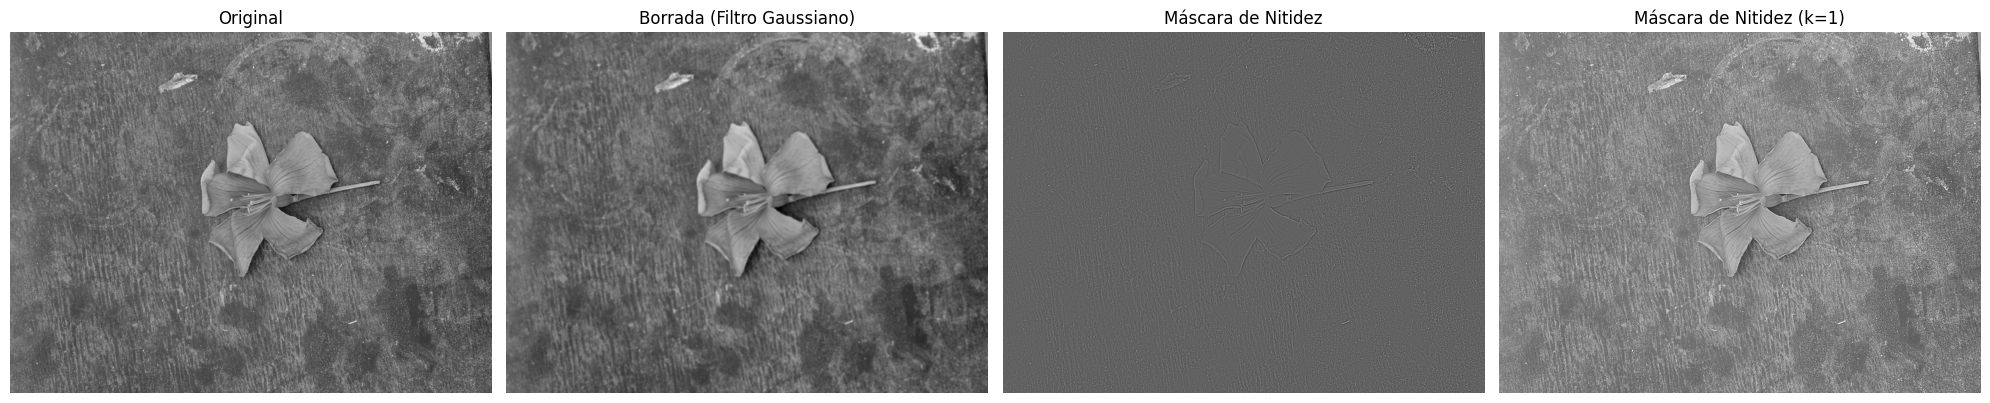

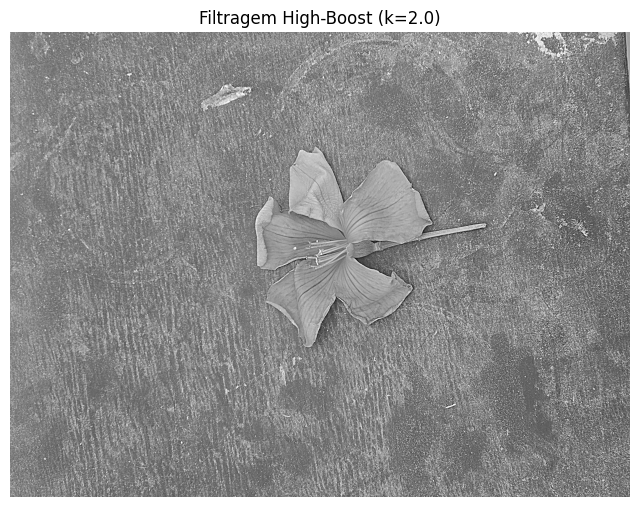

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage import io, color, util, filters

image_path = './images/flor_i_d_01.jpg'

try:
    image = io.imread(image_path)
    if image is None:
        raise FileNotFoundError("Erro: Imagem não encontrada. Verifique o nome do arquivo.")
except FileNotFoundError as e:
    print(e)
    exit()

# Converter para escala de cinza
if image.ndim > 2:
    grayscale_img = color.rgb2gray(image)
else:
    grayscale_img = image

# Aplicando o Gaussian Blur
img_borrada = filters.gaussian(grayscale_img, sigma=1.0)

# Obter a Máscara de Nitidez
mascara_nitidez = grayscale_img - img_borrada

# Máscara de Nitidez (k = 1)
k_nitidez = 1.0
img_nitidez = grayscale_img + k_nitidez * mascara_nitidez

# Filtragem High-Boost (k > 1)
k_high_boost = 2.0
img_high_boost = grayscale_img + k_high_boost * mascara_nitidez

# Evitando valores fora do intervalo [0, 1] ou [0, 255]
img_nitidez = util.img_as_ubyte(np.clip(img_nitidez, 0, 1))
img_high_boost = util.img_as_ubyte(np.clip(img_high_boost, 0, 1))

# Plotando os resultados
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# Imagem Original
axes[0].imshow(grayscale_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

# Imagem Borrada (passo 1)
axes[1].imshow(img_borrada, cmap='gray')
axes[1].set_title('Borrada (Filtro Gaussiano)')
axes[1].axis('off')

# Máscara de Nitidez (passo 2)
# A visualização pode ser ajustada para melhor contraste.
axes[2].imshow(mascara_nitidez, cmap='gray')
axes[2].set_title('Máscara de Nitidez')
axes[2].axis('off')

# Resultado da Máscara de Nitidez (k=1)
axes[3].imshow(img_nitidez, cmap='gray')
axes[3].set_title('Máscara de Nitidez (k=1)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

# Filtragem High-Boost
plt.figure(figsize=(8, 8))
plt.imshow(img_high_boost, cmap='gray')
plt.title(f'Filtragem High-Boost (k={k_high_boost})')
plt.axis('off')
plt.show()

io.imsave('filtered/T9-imagem_nitidez.png', img_nitidez)
io.imsave('filtered/T9-imagem_high_boost.png', img_high_boost)